In [2]:
# ---------------------------------------------------
# Importation des bibliothèques nécessaires
# ---------------------------------------------------
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Style des graphiques
sns.set()

In [3]:
# ---------------------------------------------------
# Chargement du fichier Housing.csv
# ---------------------------------------------------
# Assurez-vous que le fichier Housing.csv se trouve dans le même dossier que le notebook
df = pd.read_csv("Housing.csv")

# Affichage des premières lignes pour vérifier
df.head()

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished


In [4]:
# ---------------------------------------------------
# Informations générales sur le dataset
# ---------------------------------------------------
df.info()        # Types des colonnes + valeurs manquantes
df.describe()    # Statistiques générales
df.isnull().sum() # Nombre de valeurs manquantes par colonne

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 545 entries, 0 to 544
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   price             545 non-null    int64 
 1   area              545 non-null    int64 
 2   bedrooms          545 non-null    int64 
 3   bathrooms         545 non-null    int64 
 4   stories           545 non-null    int64 
 5   mainroad          545 non-null    object
 6   guestroom         545 non-null    object
 7   basement          545 non-null    object
 8   hotwaterheating   545 non-null    object
 9   airconditioning   545 non-null    object
 10  parking           545 non-null    int64 
 11  prefarea          545 non-null    object
 12  furnishingstatus  545 non-null    object
dtypes: int64(6), object(7)
memory usage: 55.5+ KB


price               0
area                0
bedrooms            0
bathrooms           0
stories             0
mainroad            0
guestroom           0
basement            0
hotwaterheating     0
airconditioning     0
parking             0
prefarea            0
furnishingstatus    0
dtype: int64

In [5]:
# ---------------------------------------------------
# Suppression des lignes contenant des valeurs manquantes
# ---------------------------------------------------
df = df.dropna()

# Vérification après nettoyage
df.isnull().sum()

price               0
area                0
bedrooms            0
bathrooms           0
stories             0
mainroad            0
guestroom           0
basement            0
hotwaterheating     0
airconditioning     0
parking             0
prefarea            0
furnishingstatus    0
dtype: int64

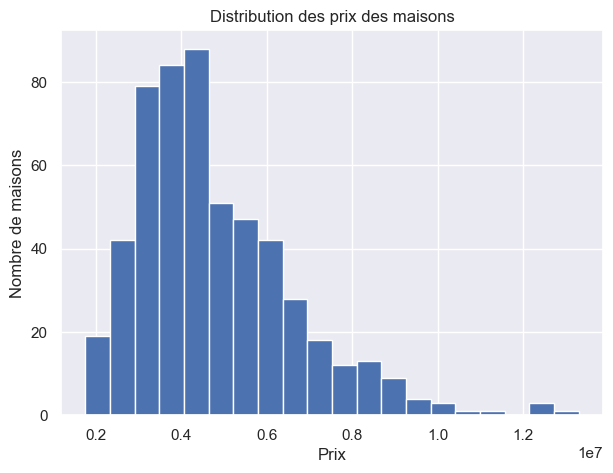

In [6]:
# ---------------------------------------------------
# Visualisation de la distribution des prix
# ---------------------------------------------------
plt.figure(figsize=(7,5))
plt.hist(df["price"], bins=20)
plt.title("Distribution des prix des maisons")
plt.xlabel("Prix")
plt.ylabel("Nombre de maisons")
plt.show()

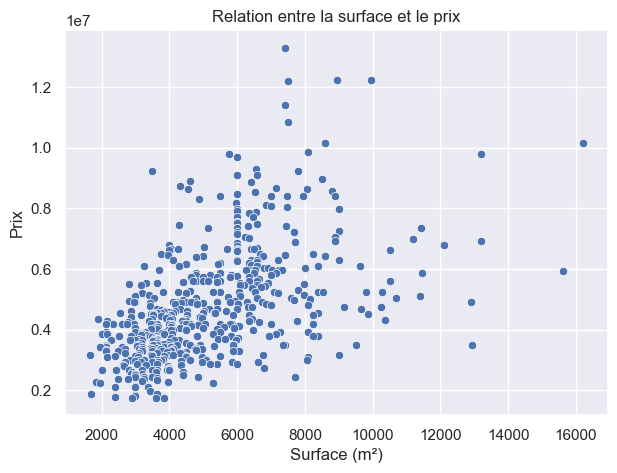

In [7]:
# ---------------------------------------------------
# Analyse de la relation entre la surface et le prix
# ---------------------------------------------------
plt.figure(figsize=(7,5))
sns.scatterplot(x="area", y="price", data=df)
plt.title("Relation entre la surface et le prix")
plt.xlabel("Surface (m²)")
plt.ylabel("Prix")
plt.show()

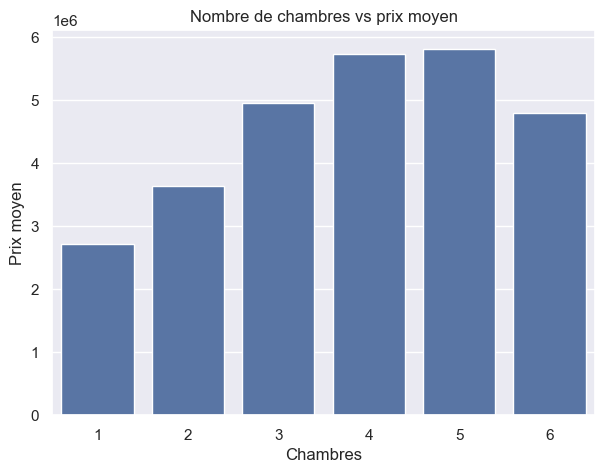

In [8]:
# ---------------------------------------------------
# Relation entre le nombre de chambres et le prix
# ---------------------------------------------------
plt.figure(figsize=(7,5))
sns.barplot(x="bedrooms", y="price", data=df, errorbar=None)
plt.title("Nombre de chambres vs prix moyen")
plt.xlabel("Chambres")
plt.ylabel("Prix moyen")
plt.show()

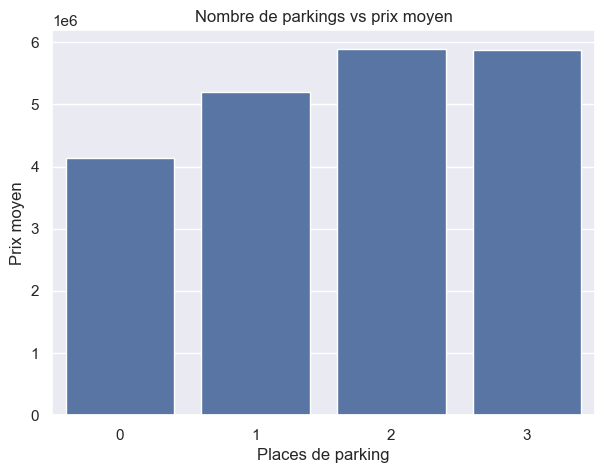

In [9]:
# ---------------------------------------------------
# Impact du nombre de places de parking sur le prix
# ---------------------------------------------------
plt.figure(figsize=(7,5))
sns.barplot(x="parking", y="price", data=df, errorbar=None)
plt.title("Nombre de parkings vs prix moyen")
plt.xlabel("Places de parking")
plt.ylabel("Prix moyen")
plt.show()

In [10]:
# ---------------------------------------------------
# Transformation des colonnes yes/no en variables numériques
# ---------------------------------------------------
df_encoded = pd.get_dummies(df, drop_first=True)

# Aperçu du nouveau dataset encodé
df_encoded.head()

,price,area,bedrooms,bathrooms,stories,parking,mainroad_yes,guestroom_yes,basement_yes,hotwaterheating_yes,airconditioning_yes,prefarea_yes,furnishingstatus_semi-furnished,furnishingstatus_unfurnished
0,13300000,7420,4,2,3,2,True,False,False,False,True,True,False,False
1,12250000,8960,4,4,4,3,True,False,False,False,True,False,False,False
2,12250000,9960,3,2,2,2,True,False,True,False,False,True,True,False
3,12215000,7500,4,2,2,3,True,False,True,False,True,True,False,False
4,11410000,7420,4,1,2,2,True,True,True,False,True,False,False,False


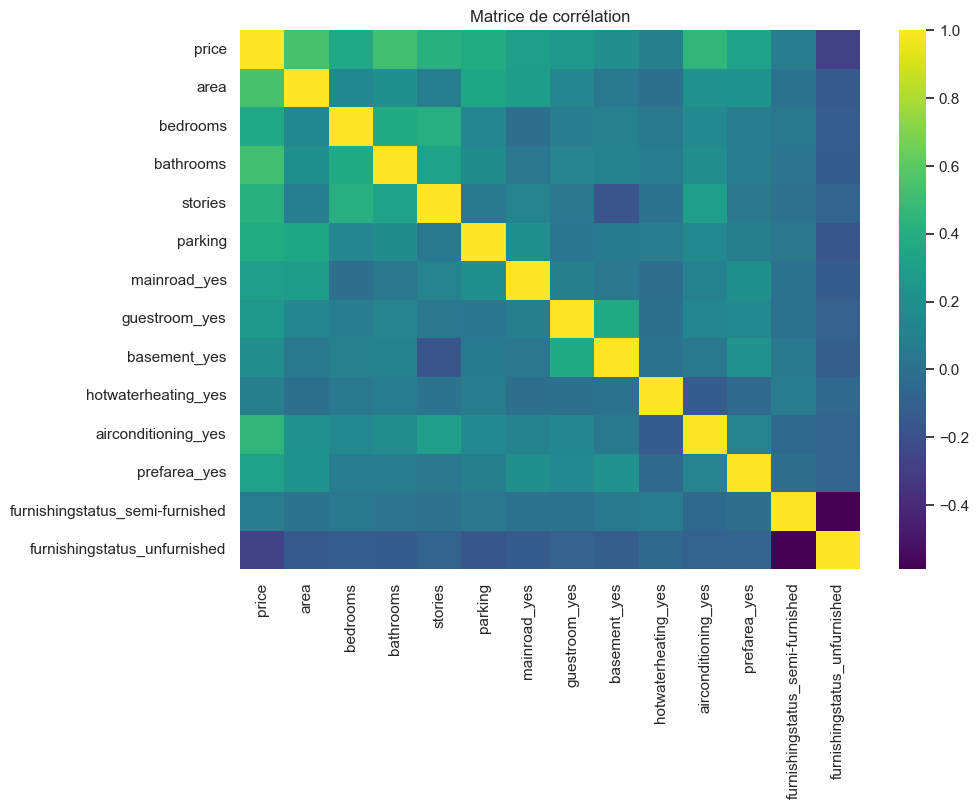

In [11]:
# ---------------------------------------------------
# Analyse de corrélation entre les variables
# ---------------------------------------------------
plt.figure(figsize=(10,7))
sns.heatmap(df_encoded.corr(), annot=False, cmap="viridis")
plt.title("Matrice de corrélation")
plt.show()